### Note

In [1]:
from typing import TypedDict, Annotated
from langgraph.graph import START, END, StateGraph
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from IPython.display import Image

In [2]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [3]:
llm = ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001EE321BD2E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001EE32183C80>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [4]:
llm.invoke("what is machine learning")

AIMessage(content="**Machine Learning: A Branch of Artificial Intelligence**\n===========================================================\n\nMachine learning is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. It allows systems to learn from data, identify patterns, and make predictions or decisions with minimal human intervention.\n\n**Key Characteristics of Machine Learning:**\n\n1. **Data-driven**: Machine learning relies on data to learn and improve its performance.\n2. **Algorithmic**: Machine learning uses algorithms to analyze data and make predictions or decisions.\n3. **Self-improving**: Machine learning systems can improve their performance over time as they receive more data.\n4. **Autonomous**: Machine learning systems can operate independently, without human intervention.\n\n**Types of Machine Learning:**\n\n1. **Supervised Learning**: The system is t

### State

In [5]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

## Nodes

In [6]:
def superbot(state:State):
    print("supper bot is calling")
    return {"messages": llm.invoke(state['messages'])}

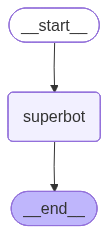

In [ ]:
# Build graph
graph = StateGraph(State)

# Node
graph.add_node("superbot", superbot)

# Edges
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

# Compile graph
graph_builder = graph.compile()

# display the graph
Image(graph_builder.get_graph().draw_mermaid_png())


In [8]:
graph_builder.invoke({"messages": "what is machine learning"})

supper bot is calling


{'messages': [HumanMessage(content='what is machine learning', additional_kwargs={}, response_metadata={}, id='764e5644-bcd7-4653-b045-16e34e3cf8f8'),
  AIMessage(content="**Machine Learning: An Overview**\n=====================================\n\nMachine learning (ML) is a subset of artificial intelligence (AI) that involves the use of algorithms and statistical models to enable machines to perform tasks without being explicitly programmed. In other words, machine learning allows computers to learn from data and improve their performance on a task over time, without being explicitly told what to do.\n\n**Key Characteristics of Machine Learning:**\n\n1. **Learning from Data**: Machine learning algorithms learn from data, rather than being programmed with explicit rules.\n2. **Improving Performance**: Machine learning models improve their performance on a task over time, as they are exposed to more data.\n3. **Generalization**: Machine learning models can generalize to new, unseen data,

In [9]:
graph_builder.invoke({"messages": "what is deep learning"})

supper bot is calling


{'messages': [HumanMessage(content='what is deep learning', additional_kwargs={}, response_metadata={}, id='37761a09-fad4-4229-bd8d-58ffa23b2a79'),
  AIMessage(content='Deep learning is a subfield of machine learning that involves the use of artificial neural networks to analyze and interpret data. It is called "deep" because it uses multiple layers of neural networks to learn complex patterns in data.\n\n**Key Characteristics of Deep Learning:**\n\n1. **Artificial Neural Networks**: Deep learning uses artificial neural networks, which are composed of multiple layers of interconnected nodes (neurons) that process and transmit information.\n2. **Multiple Layers**: Deep learning models typically consist of multiple layers, including input layers, hidden layers, and output layers. Each layer processes and transforms the input data in a different way.\n3. **Hierarchical Representations**: Deep learning models learn hierarchical representations of data, where early layers learn low-level fe

In [10]:
graph_builder.invoke({"messages": "tell me about CNN"})

supper bot is calling


{'messages': [HumanMessage(content='tell me about CNN', additional_kwargs={}, response_metadata={}, id='63bf76c6-5691-481f-9743-eebce57c285f'),
  AIMessage(content="CNN (Cable News Network) is a multinational news organization that provides 24-hour coverage of news, sports, and entertainment. Here's an overview:\n\n**History**: CNN was launched on June 1, 1980, by Ted Turner and his company, Turner Broadcasting System (TBS). It was the first 24-hour cable news channel, revolutionizing the way people consumed news.\n\n**Programming**: CNN offers a wide range of programming, including:\n\n1. **News**: Breaking news, in-depth coverage, and analysis of national and international events.\n2. **Politics**: Coverage of elections, government, and policy issues.\n3. **Business**: Financial news, market analysis, and business trends.\n4. **Sports**: Highlights, analysis, and live coverage of various sports events.\n5. **Entertainment**: Celebrity news, movie reviews, and entertainment-related pr

In [11]:
for response in graph_builder.stream({"messages": "tell me about RNN"}, stream_mode="values"):
    print(response)

{'messages': [HumanMessage(content='tell me about RNN', additional_kwargs={}, response_metadata={}, id='1b452666-2b66-4e34-b8b4-c60c2fcf67dd')]}
supper bot is calling
{'messages': [HumanMessage(content='tell me about RNN', additional_kwargs={}, response_metadata={}, id='1b452666-2b66-4e34-b8b4-c60c2fcf67dd'), AIMessage(content="**Recurrent Neural Networks (RNNs)**\n=====================================\n\nA Recurrent Neural Network (RNN) is a type of artificial neural network that is designed to handle sequential data, such as time series data, speech, or text. RNNs are particularly useful for modeling temporal relationships in data, where the output at a given time step depends on the previous time steps.\n\n**Key Components of RNNs**\n---------------------------\n\n1. **Cells**: The basic building block of an RNN is the cell, which is a neural network that takes in the current input and the previous hidden state to produce the next hidden state.\n2. **Hidden State**: The hidden state

In [ ]:
# show all step 
for response in graph_builder.stream({"messages": "tell me about DNN"}, stream_mode="values"):
    print(response)

{'messages': [HumanMessage(content='tell me about DNN', additional_kwargs={}, response_metadata={}, id='b475b86b-a348-436f-aa63-d509c7c08f1a')]}
supper bot is calling
{'messages': [HumanMessage(content='tell me about DNN', additional_kwargs={}, response_metadata={}, id='b475b86b-a348-436f-aa63-d509c7c08f1a'), AIMessage(content='**Introduction to DNN (Deep Neural Networks)**\n=============================================\n\nA Deep Neural Network (DNN) is a type of artificial neural network with multiple layers of interconnected nodes or "neurons." DNNs are designed to mimic the structure and function of the human brain, allowing them to learn and represent complex patterns in data.\n\n**Key Components of DNNs**\n-------------------------\n\n1. **Artificial Neurons (Nodes)**: These are the basic building blocks of DNNs, which receive one or more inputs, perform a computation on those inputs, and produce an output.\n2. **Layers**: DNNs are composed of multiple layers, each of which consis

In [ ]:
# show result only
for response in graph_builder.stream({"messages": "tell me about RNN"}, stream_mode="updates"):
    print(response)

supper bot is calling
{'superbot': {'messages': AIMessage(content='**Recurrent Neural Networks (RNNs)**\n=====================================\n\nA Recurrent Neural Network (RNN) is a type of neural network that is designed to handle sequential data, such as time series data, speech, or text. RNNs are particularly useful for modeling temporal relationships in data, where the order of the input matters.\n\n**Key Features of RNNs**\n------------------------\n\n1. **Recurrent Connections**: RNNs have recurrent connections, which allow the network to keep track of information over time.\n2. **Hidden State**: RNNs have a hidden state, which captures the internal state of the network at each time step.\n3. **Sequential Input**: RNNs process sequential input data, one step at a time.\n\n**How RNNs Work**\n-----------------\n\n1. **Input**: The network receives the input data at each time step.\n2. **Hidden State Update**: The network updates the hidden state based on the current input and the